<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementando Lógica de Componentes Principais e Análise Fatorial**

A partir de rte_cereal.csv faça as seguintes análises e justifique TODAS:

1 ) Rode uma análise descritiva dos dados, em relação as correlações das variáveis e avalie as correlações. Resuma estas correlações


In [24]:
from matplotlib import pyplot as plt # importando a biblioteca de visualização de dados
import pandas as pd # importando a biblioteca de manipulação de dados
import seaborn as sns
import numpy as np

# URL COMPLETA da sua planilha
url = "https://docs.google.com/spreadsheets/d/1oGs_Lyu2kaNveIf7f9g_-crd3SHyT9cRBAb8zOfNHp8/edit?gid=318916012#gid=318916012"

# Transforma o link em formato de exportação CSV
url_csv = url.replace("/edit?", "/export?format=csv&")

# Lê os dados diretamente da planilha
base_banco = pd.read_csv(url_csv)

# Dicionário de mapeamento (colunas antigas → novas)
mapeamento_colunas = {
    'Col1': 'Respondente',
    'Col2': 'Marca',
    'Col3': 'Satisfaz',
    'Col4': 'Natural',
    'Col5': 'Fibra',
    'Col6': 'Doce',
    'Col7': 'Fácil',
    'Col8': 'Sal',
    'Col9': 'Gratificante',
    'Col10': 'Energia',
    'Col11': 'Divertido',
    'Col12': 'Crianças',
    'Col13': 'Encharcado',
    'Col14': 'Econômico',
    'Col15': 'Saúde',
    'Col16': 'Família',
    'Col17': 'Calorias',
    'Col18': 'Simples',
    'Col19': 'Crocante',
    'Col20': 'Regular',
    'Col21': 'Açúcar',
    'Col22': 'Fruta',
    'Col23': 'Processo',
    'Col24': 'Qualidade',
    'Col25': 'Prazer',
    'Col26': 'Chato',
    'Col27': 'Nutritivo'
}

# Renomeia as colunas assim que a planilha é lida
base_banco = base_banco.rename(columns=mapeamento_colunas)

base_banco.head()

,Respondente,Marca,Satisfaz,Natural,Fibra,Doce,Fácil,Sal,Gratificante,Energia,...,Simples,Crocante,Regular,Açúcar,Fruta,Processo,Qualidade,Prazer,Chato,Nutritivo
0,101,25,5,5,5,1,2,1,5,4,...,3,1,4,1,1,3,5,1,1,5
1,101,21,1,2,2,1,5,2,5,1,...,5,5,1,2,1,5,2,1,1,3
2,103,21,5,4,5,5,5,3,5,5,...,1,5,4,3,1,2,5,4,1,5
3,103,3,5,5,5,3,5,2,5,5,...,1,1,4,2,5,2,5,5,1,5
4,104,14,4,5,3,2,5,2,5,4,...,1,5,3,1,1,3,5,5,1,4


In [40]:
base_banco.describe()

,Respondente,Marca,Satisfaz,Natural,Fibra,Doce,Fácil,Sal,Gratificante,Energia,...,Simples,Crocante,Regular,Açúcar,Fruta,Processo,Qualidade,Prazer,Chato,Nutritivo
count,235.000000,235.000000,235.000000,235.000000,235.00000,235.000000,235.000000,235.000000,235.000000,235.000000,...,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,374.808511,16.906383,3.880851,3.782979,3.52766,2.506383,4.531915,1.991489,4.004255,3.642553,...,2.268085,3.204255,3.072340,2.144681,1.693617,2.936170,3.693617,2.629787,1.829787,3.663830
std,200.698102,6.794272,0.883524,0.886585,0.99694,1.122308,0.774902,0.832007,0.813864,0.896275,...,1.090187,1.212816,1.150567,1.044073,1.081982,1.143623,0.910387,1.255401,0.945506,0.887815
min,101.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,2.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204.500000,14.000000,3.000000,3.000000,3.00000,2.000000,4.000000,1.000000,3.000000,3.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000,3.000000,2.000000,1.000000,3.000000
50%,315.000000,17.000000,4.000000,4.000000,4.00000,2.000000,5.000000,2.000000,4.000000,4.000000,...,2.000000,3.000000,3.000000,2.000000,1.000000,3.000000,4.000000,3.000000,2.000000,4.000000
75%,608.500000,23.000000,4.500000,4.000000,4.00000,3.000000,5.000000,3.000000,5.000000,4.000000,...,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,2.000000,4.000000
max,639.000000,25.000000,5.000000,5.000000,5.00000,5.000000,6.000000,4.000000,6.000000,5.000000,...,5.000000,6.000000,5.000000,5.000000,5.000000,6.000000,5.000000,6.000000,5.000000,5.000000


Para que a análise fatorial seja adequada, as variáveis devem ser correlacionadas. Espera-se também que as variáveis altamente correlacionadas umas com as outras se correlacionem também com o(s) mesmo(s) fatore(s).

In [26]:
# Seleciona apenas colunas de interesse (de Satisfaz a Nutritivo)
atributos = base_banco.loc[:, "Satisfaz":"Nutritivo"]

# Calcula a matriz de correlação
matcor = atributos.corr()

# Exibe a matriz com 2 casas decimais
print(matcor.round(2))

              Satisfaz  Natural  Fibra  Doce  Fácil   Sal  Gratificante  \
Satisfaz          1.00     0.54   0.55  0.19   0.24 -0.04          0.65   
Natural           0.54     1.00   0.65 -0.09   0.23 -0.22          0.46   
Fibra             0.55     0.65   1.00 -0.04   0.17 -0.17          0.41   
Doce              0.19    -0.09  -0.04  1.00   0.13  0.44          0.18   
Fácil             0.24     0.23   0.17  0.13   1.00  0.03          0.36   
Sal              -0.04    -0.22  -0.17  0.44   0.03  1.00          0.00   
Gratificante      0.65     0.46   0.41  0.18   0.36  0.00          1.00   
Energia           0.64     0.49   0.50  0.18   0.18 -0.07          0.60   
Divertido         0.27     0.08   0.06  0.33   0.25  0.03          0.35   
Crianças          0.16     0.06  -0.09  0.12   0.25  0.03          0.31   
Encharcado       -0.06     0.07  -0.04 -0.08  -0.01  0.02         -0.01   
Econômico         0.05     0.10  -0.03 -0.24   0.09 -0.13          0.21   
Saúde             0.55   

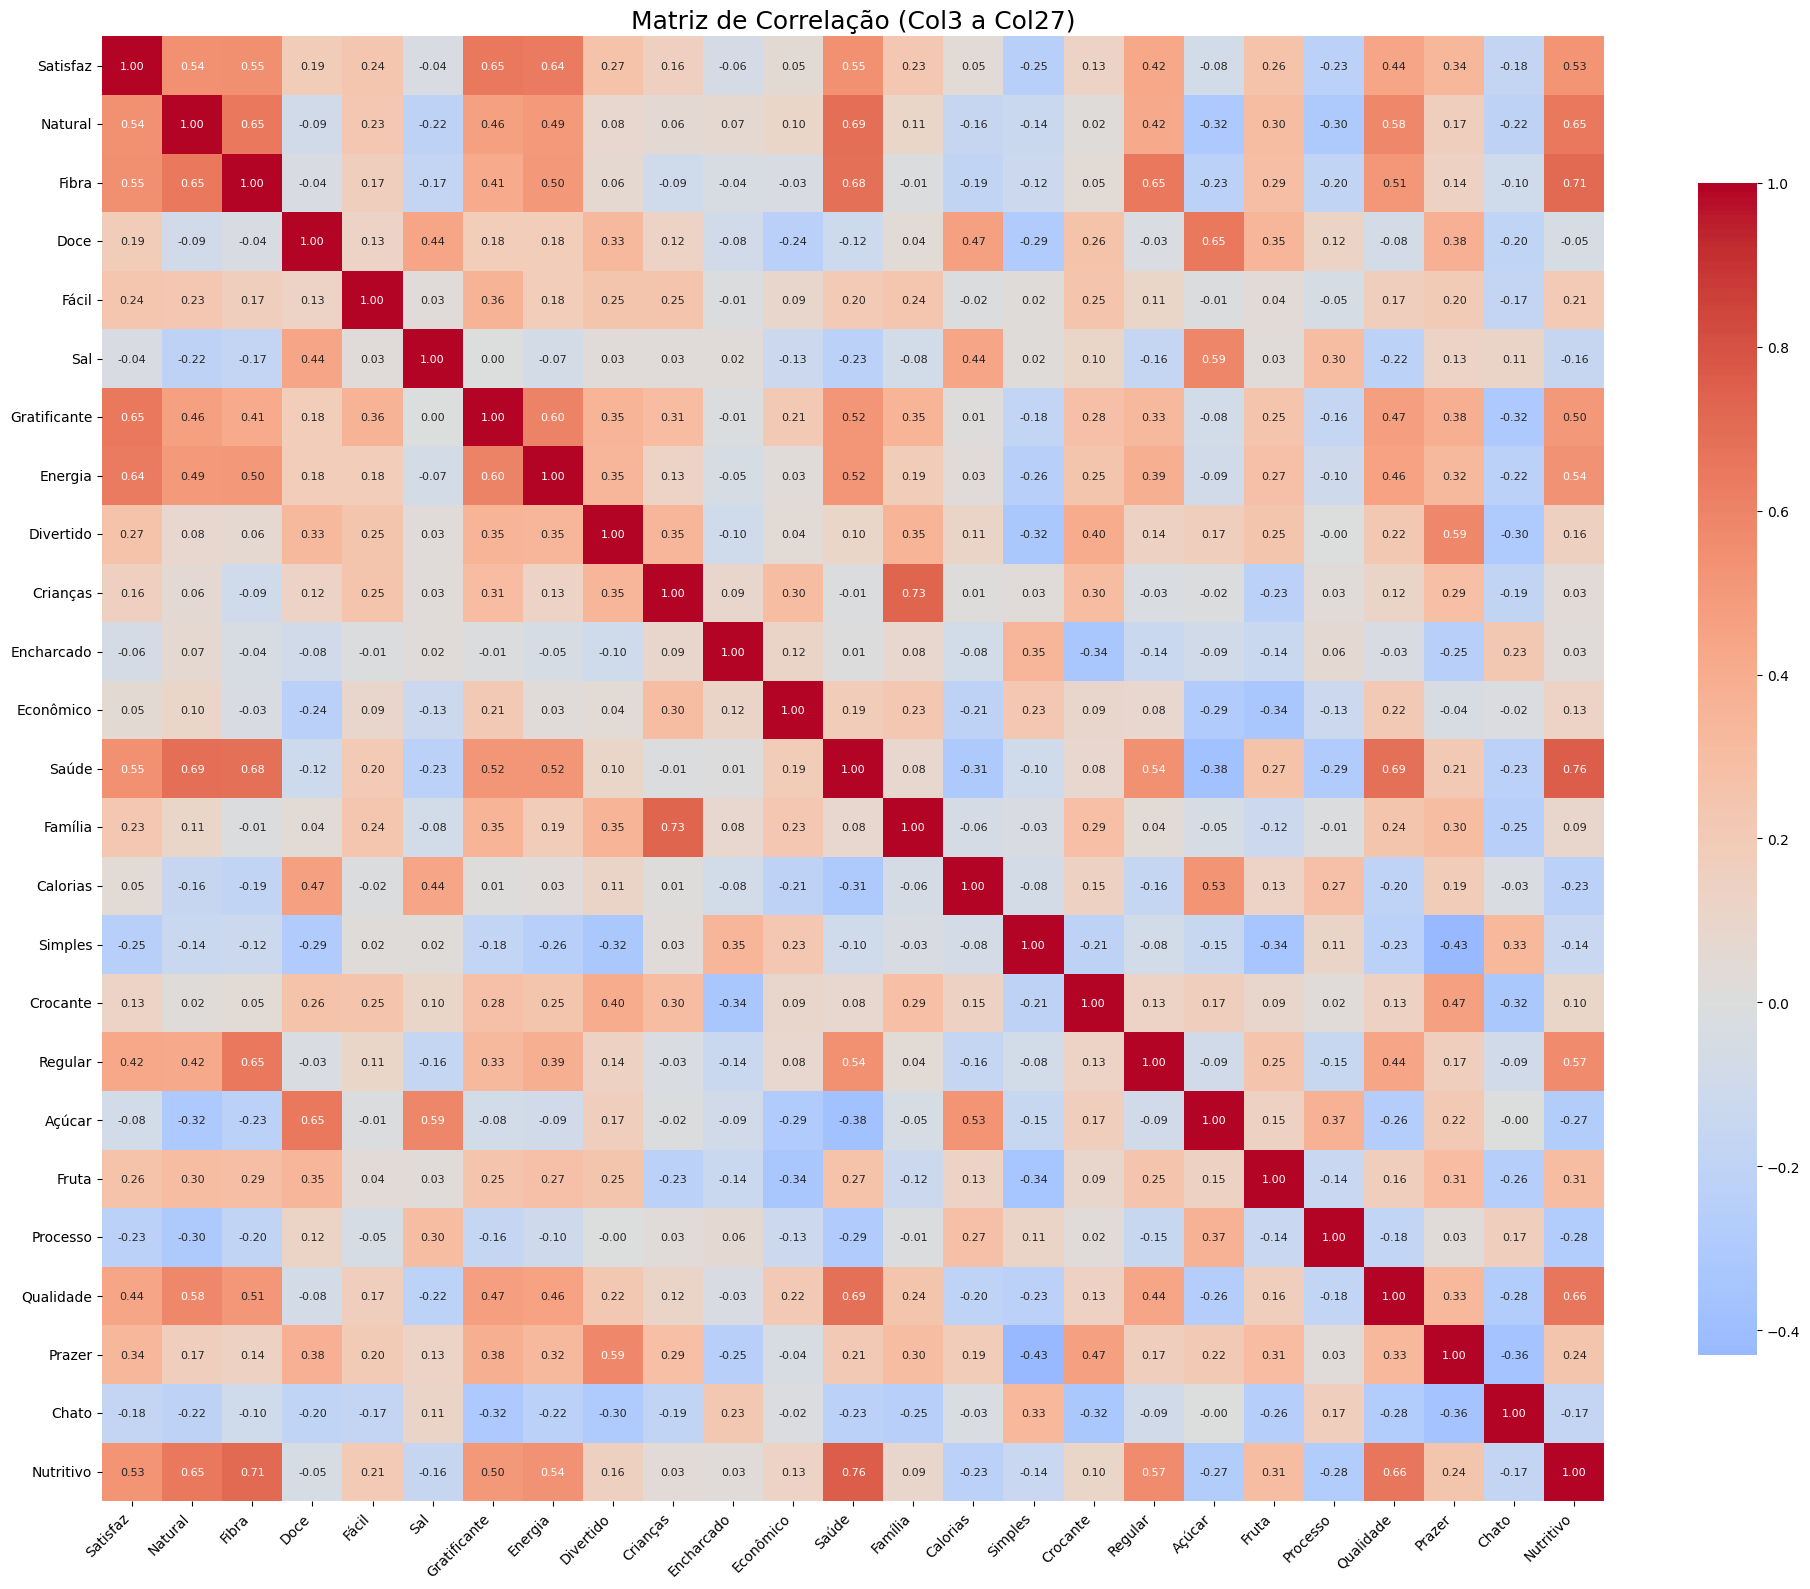

In [27]:
plt.figure(figsize=(20, 16))  # Aumente aqui o tamanho da imagem
sns.heatmap(
    matcor,
    annot=True,              # mostra os valores
    cmap='coolwarm',
    fmt='.2f',
    center=0,
    annot_kws={"size": 8},   # controla o tamanho dos números
    cbar_kws={"shrink": 0.8} # ajusta o tamanho da barra lateral
)
plt.title('Matriz de Correlação (Col3 a Col27)', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)  # gira e reduz os nomes
plt.yticks(fontsize=10)
plt.tight_layout()  # evita cortes nos rótulos
plt.show()

In [28]:
# Calcular todos os pares de correlação ---
corr_pairs = matcor.unstack()

# Remove a diagonal (1.0) e pares duplicados (A-B / B-A)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_df = corr_pairs.reset_index()
corr_df.columns = ['Variável 1', 'Variável 2', 'Correlação']
corr_df['par'] = corr_df[['Variável 1', 'Variável 2']].apply(lambda x: '-'.join(sorted(x)), axis=1)
corr_df = corr_df.drop_duplicates(subset='par').drop(columns='par')

# Ordena pelo valor absoluto da correlação (do maior para o menor)
corr_df = corr_df.reindex(corr_df['Correlação'].abs().sort_values(ascending=False).index)

# --- 2. Gerar texto descritivo para todas ---
print("ANÁLISE DESCRITIVA DAS CORRELAÇÕES ENTRE TODAS AS VARIÁVEIS\n")
print(f"Total de pares avaliados: {len(corr_df)}\n")

for i, row in corr_df.iterrows():
    tipo = "positiva" if row['Correlação'] > 0 else "negativa"
    intensidade = (
        "fraca" if abs(row['Correlação']) < 0.3 else
        "moderada" if abs(row['Correlação']) < 0.7 else
        "forte"
    )
    print(f"- {row['Variável 1']} e {row['Variável 2']}: "
          f"correlação {tipo} {intensidade} (valor = {row['Correlação']:.2f})")

ANÁLISE DESCRITIVA DAS CORRELAÇÕES ENTRE TODAS AS VARIÁVEIS

Total de pares avaliados: 300

- Saúde e Nutritivo: correlação positiva forte (valor = 0.76)
- Crianças e Família: correlação positiva forte (valor = 0.73)
- Fibra e Nutritivo: correlação positiva forte (valor = 0.71)
- Natural e Saúde: correlação positiva moderada (valor = 0.69)
- Saúde e Qualidade: correlação positiva moderada (valor = 0.69)
- Fibra e Saúde: correlação positiva moderada (valor = 0.68)
- Qualidade e Nutritivo: correlação positiva moderada (valor = 0.66)
- Natural e Fibra: correlação positiva moderada (valor = 0.65)
- Natural e Nutritivo: correlação positiva moderada (valor = 0.65)
- Satisfaz e Gratificante: correlação positiva moderada (valor = 0.65)
- Doce e Açúcar: correlação positiva moderada (valor = 0.65)
- Fibra e Regular: correlação positiva moderada (valor = 0.65)
- Satisfaz e Energia: correlação positiva moderada (valor = 0.64)
- Gratificante e Energia: correlação positiva moderada (valor = 0.60)
- 

Obtenha os autovalores e autovetores da matriz de covariâncias

In [39]:
# Calcular a matriz de covariâncias
matcov = np.cov(base_banco.iloc[:, 2:].T)  # assumindo que Col3 a Col27 são as variáveis numéricas

# Calcular autovalores e autovetores
autovalores_cov, autovetores_cov = np.linalg.eig(matcov)

# Exibir autovalores com duas casas decimais
print("\nAutovalores (matriz de covariâncias):")
print(pd.DataFrame(autovalores_cov, columns=['Autovalores']).to_string(index=False, float_format="%.2f"))

# Exibir autovetores com duas casas decimais
print("\nAutovetores (matriz de covariâncias):")
print(pd.DataFrame(autovetores_cov).to_string(index=False, float_format="%.2f"))


Autovalores (matriz de covariâncias):
 Autovalores
        6.28
        4.38
        3.11
        1.88
        1.40
        1.08
        0.96
        0.87
        0.80
        0.71
        0.15
        0.17
        0.19
        0.22
        0.24
        0.26
        0.30
        0.36
        0.39
        0.40
        0.43
        0.51
        0.56
        0.64
        0.63

Autovetores (matriz de covariâncias):
   0     1     2     3     4     5     6     7     8     9     10    11    12    13    14    15    16    17    18    19    20    21    22    23    24
 0.25  0.07 -0.05 -0.16 -0.02  0.14 -0.16 -0.14 -0.15  0.31  0.13  0.22  0.53  0.09 -0.44  0.09 -0.20 -0.11  0.19  0.21 -0.18 -0.07 -0.01  0.06  0.00
 0.21  0.21 -0.06 -0.12 -0.06  0.06 -0.09 -0.11  0.17  0.03  0.25 -0.28 -0.16  0.34 -0.10 -0.47 -0.41 -0.01 -0.22 -0.11  0.29  0.04  0.02  0.03  0.07
 0.24  0.23 -0.18 -0.16  0.17 -0.04 -0.13  0.10 -0.01  0.06 -0.16  0.36 -0.29 -0.27  0.14  0.38 -0.47 -0.04 -0.23 -0.01  0.06  0.11  0

Obtenha os autovalores e autovetores da matriz de correlações

In [38]:
# Calcular autovalores e autovetores da matriz de correlação
autovalores, autovetores = np.linalg.eig(matcor)

# Exibir autovalores com duas casas decimais
print("\nAutovalores (matriz de correlação):")
print(pd.DataFrame(autovalores, columns=['Autovalores']).to_string(index=False, float_format="%.2f"))

# Exibir autovetores com duas casas decimais
print("\nAutovetores (matriz de correlação):")
print(pd.DataFrame(autovetores).to_string(index=False, float_format="%.2f"))


Autovalores (matriz de correlação):
 Autovalores
        6.50
        3.82
        2.50
        1.68
        1.09
        0.93
        0.85
        0.79
        0.73
        0.70
        0.65
        0.55
        0.53
        0.49
        0.16
        0.20
        0.22
        0.24
        0.26
        0.27
        0.30
        0.42
        0.39
        0.36
        0.36

Autovetores (matriz de correlação):
   0     1     2     3     4     5     6     7     8     9     10    11    12    13    14    15    16    17    18    19    20    21    22    23    24
-0.29 -0.05 -0.05 -0.17  0.11  0.01  0.26  0.39  0.02  0.05 -0.05  0.11 -0.08  0.11  0.01 -0.23 -0.41  0.11  0.42 -0.02 -0.25  0.12  0.05 -0.31 -0.15
-0.29  0.13 -0.08 -0.10  0.14  0.06  0.00 -0.06  0.21 -0.08 -0.05 -0.28 -0.11 -0.09 -0.31  0.04 -0.03  0.05 -0.33 -0.01 -0.44 -0.25 -0.39  0.11 -0.25
-0.29  0.13 -0.21 -0.14 -0.16 -0.02 -0.13  0.13 -0.02 -0.18 -0.04 -0.03  0.01 -0.15  0.34 -0.18  0.51 -0.26  0.17 -0.35  0.09  0.02 -0.22 

Use as variáveis ‘Col3’ e ‘Col4’ e obtenha a matriz de covariâncias só destas 2.

In [41]:
# Selecionar apenas as duas variáveis desejadas
subset = base_banco[['Satisfaz', 'Natural']]  # Col3 e Col4 (já com nomes renomeados)

# Calcular a matriz de covariâncias
matriz_cov_2 = np.cov(subset.T)

# Exibir a matriz como DataFrame para visualização
matriz_cov_df = pd.DataFrame(
    matriz_cov_2,
    index=subset.columns,
    columns=subset.columns
)

print("\nMatriz de Covariâncias entre 'Satisfaz' e 'Natural':")
print(matriz_cov_df.round(3))


Matriz de Covariâncias entre 'Satisfaz' e 'Natural':
          Satisfaz  Natural
Satisfaz     0.781    0.423
Natural      0.423    0.786
